In [1]:
"""
vit_runner.py — Vision Transformer (ViT-B/32) from scratch + CLIP demo
=======================================================================
Run all 7 ViT steps with numerical output, then compare against real CLIP.

Usage
-----
  python vit_runner.py                        # all steps, synthetic image
  python vit_runner.py --image path/to/img   # your own image
  python vit_runner.py --step 1              # single step only (1-7)
  python vit_runner.py --clip                # enable CLIP comparison
  python vit_runner.py --no-plots            # skip matplotlib windows
  python vit_runner.py --clip --image apple.jpg --no-plots
"""

'\nvit_runner.py — Vision Transformer (ViT-B/32) from scratch + CLIP demo\n=======================================================================\nRun all 7 ViT steps with numerical output, then compare against real CLIP.\n \nUsage\n-----\n  python vit_runner.py                        # all steps, synthetic image\n  python vit_runner.py --image path/to/img   # your own image\n  python vit_runner.py --step 1              # single step only (1-7)\n  python vit_runner.py --clip                # enable CLIP comparison\n  python vit_runner.py --no-plots            # skip matplotlib windows\n  python vit_runner.py --clip --image apple.jpg --no-plots\n'

In [2]:

import argparse
import sys
import math
import textwrap
import time

In [4]:
# ── dependency check ─────────────────────────────────────────────────────────
def _require(pkg, install_as=None):
    import importlib
    try:
        return importlib.import_module(pkg)
    except ImportError:
        name = install_as or pkg
        print(f"[setup] Installing {name} …")
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", name, "-q"])
        return importlib.import_module(pkg)

torch      = _require("torch")
nn         = torch.nn
F          = torch.nn.functional
np         = _require("numpy")
_require("torchvision")
_require("PIL", "Pillow")

from torchvision import transforms
from PIL import Image
import io, urllib.request

torch.manual_seed(42)
np.random.seed(42)


In [5]:
# ── terminal colours ──────────────────────────────────────────────────────────
RESET  = "\033[0m";  BOLD   = "\033[1m"
CYAN   = "\033[96m"; GREEN  = "\033[92m"; YELLOW = "\033[93m"
RED    = "\033[91m"; DIM    = "\033[2m";  MAGENTA= "\033[95m"

def hdr(text):   print(f"\n{BOLD}{CYAN}{'─'*60}{RESET}\n{BOLD}{CYAN}  {text}{RESET}\n{BOLD}{CYAN}{'─'*60}{RESET}")
def ok(text):    print(f"  {GREEN}✓{RESET}  {text}")
def info(text):  print(f"  {YELLOW}→{RESET}  {text}")
def dim(text):   print(f"  {DIM}{text}{RESET}")
def section(n, title): print(f"\n{BOLD}{MAGENTA}Step {n} — {title}{RESET}")

def shape_str(t):
    return f"{CYAN}{list(t.shape)}{RESET}"

def bar_chart(labels, values, width=30):
    """Simple ASCII horizontal bar chart."""
    max_v = max(abs(v) for v in values) or 1
    for lbl, val in zip(labels, values):
        filled = int(abs(val) / max_v * width)
        color  = GREEN if val >= 0 else RED
        bar    = color + "█" * filled + RESET + "░" * (width - filled)
        print(f"  {lbl:<35s} {bar}  {val:+.4f}")

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Model components
# ══════════════════════════════════════════════════════════════════════════════

class PatchEmbedding(nn.Module):
    """Conv2d(3, D, kernel=P, stride=P)  ≡  Linear(P²·3, D) per patch."""
    def __init__(self, patch_size=32, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # [B, D, n_h, n_w]
        x = x.flatten(2)           # [B, D, N]
        return x.transpose(1, 2)   # [B, N, D]


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=768, n_heads=12):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = embed_dim // n_heads
        self.scale    = self.head_dim ** -0.5
        self.qkv      = nn.Linear(embed_dim, embed_dim * 3)
        self.out      = nn.Linear(embed_dim, embed_dim)
        self._attn    = None   # stored for inspection

    def forward(self, x):
        B, N, D = x.shape
        H, hd   = self.n_heads, self.head_dim
        qkv = self.qkv(x).reshape(B, N, 3, H, hd).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = F.softmax((q @ k.transpose(-2, -1)) * self.scale, dim=-1)
        self._attn = attn.detach()
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.out(x)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=768, n_heads=12, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, n_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        hd = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, hd), nn.GELU(), nn.Linear(hd, embed_dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViTB32(nn.Module):
    """ViT-Base/32 — all 7 steps in one module."""
    def __init__(self, img_size=224, patch_size=32, embed_dim=768,
                 depth=12, n_heads=12, n_classes=1000, clip_dim=None):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2   # 49

        self.patch_embed = PatchEmbedding(patch_size, embed_dim)              # step 2
        self.cls_token   = nn.Parameter(torch.randn(1, 1, embed_dim))        # step 3
        self.pos_embed   = nn.Parameter(                                      # step 4
            torch.randn(1, n_patches + 1, embed_dim) * 0.02)
        self.blocks      = nn.ModuleList(                                     # step 5
            [TransformerBlock(embed_dim, n_heads) for _ in range(depth)])
        self.norm        = nn.LayerNorm(embed_dim)
        # step 7
        self.head = (nn.Linear(embed_dim, clip_dim, bias=False)
                     if clip_dim else nn.Linear(embed_dim, n_classes))
        self.clip_dim = clip_dim
        self._cls_per_layer = []

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                        # [B,49,768]
        x = torch.cat([self.cls_token.expand(B,-1,-1), x], dim=1)  # [B,50,768]
        x = x + self.pos_embed
        self._cls_per_layer = []
        for blk in self.blocks:
            x = blk(x)
            self._cls_per_layer.append(x[0, 0].detach())
        x = self.norm(x)
        cls = x[:, 0]                                  # [B,768]
        out = self.head(cls)
        if self.clip_dim:
            out = out / out.norm(dim=-1, keepdim=True)
        return out, cls


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Image loader
# ══════════════════════════════════════════════════════════════════════════════

def load_image(path=None):
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    if path:
        img = Image.open(path).convert("RGB")
        info(f"Loaded image: {path}")
    else:
        try:
            url = ("https://upload.wikimedia.org/wikipedia/commons/thumb/"
                   "1/15/Red_Apple.jpg/800px-Red_Apple.jpg")
            with urllib.request.urlopen(url, timeout=5) as r:
                img = Image.open(io.BytesIO(r.read())).convert("RGB")
            info("Fetched apple image from Wikipedia")
        except Exception:
            arr = np.zeros((224, 224, 3), dtype=np.uint8)
            arr[40:180, 50:170, 0] = 210
            arr[40:180, 50:170, 1] = 40
            arr[40:180, 50:170, 2] = 40
            img = Image.fromarray(arr)
            info("Network unavailable — using synthetic red-blob image")
    return img, preprocess(img).unsqueeze(0)   # PIL image + [1,3,224,224]


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Step runners
# ══════════════════════════════════════════════════════════════════════════════

def run_step1(img_tensor, show_plots):
    section(1, "Patch Splitting")
    P = 32
    patches_per_side = 224 // P
    n_patches  = patches_per_side ** 2
    patch_dim  = P * P * 3

    ok(f"Image shape        : {shape_str(img_tensor)}  (B, C, H, W)")
    ok(f"Patch size         : {P} × {P}")
    ok(f"Patches per side   : 224 / {P} = {patches_per_side}")
    ok(f"Total patches      : {patches_per_side} × {patches_per_side} = {n_patches}")
    ok(f"Numbers per patch  : {P} × {P} × 3 = {patch_dim}")

    # unfold into patches
    x = img_tensor.unfold(2, P, P).unfold(3, P, P)
    x = x.permute(0, 2, 3, 1, 4, 5).reshape(1, n_patches, patch_dim)
    ok(f"Patches tensor     : {shape_str(x)}")

    info("Grid preview (7×7):")
    for r in range(7):
        row = "  " + " ".join(f"P{r*7+c:02d}" for c in range(7))
        print(row)

    patch_means = x[0].mean(1).numpy()
    info(f"P0  mean pixel value : {patch_means[0]:.4f}")
    info(f"P24 mean pixel value : {patch_means[24]:.4f}  (centre patch)")
    info(f"P48 mean pixel value : {patch_means[48]:.4f}  (bottom-right)")

    if show_plots:
        import matplotlib.pyplot as plt
        img_np = img_tensor[0].permute(1, 2, 0).numpy()
        fig, axes = plt.subplots(7, 7, figsize=(8, 8))
        fig.suptitle("Step 1 — 7×7 Patch Grid", fontweight="bold")
        for idx in range(49):
            r, c = divmod(idx, 7)
            axes[r, c].imshow(img_np[r*P:(r+1)*P, c*P:(c+1)*P])
            axes[r, c].set_title(f"P{idx}", fontsize=6)
            axes[r, c].axis("off")
        plt.tight_layout(); plt.show()

    return x  # [1, 49, 3072]


def run_step2(img_tensor, show_plots):
    section(2, "Patch Embedding (Linear Projection)")
    EMBED = 768
    pe = PatchEmbedding(32, EMBED)
    embedded = pe(img_tensor)    # [1, 49, 768]
    ok(f"Input  : {shape_str(img_tensor)}")
    ok(f"Output : {shape_str(embedded)}  — 49 patches, each 768-dim")

    info("Tiny numerical example (d=4):")
    torch.manual_seed(0)
    tiny = nn.Linear(3072, 4, bias=False)
    x_flat = img_tensor.unfold(2,32,32).unfold(3,32,32)
    x_flat = x_flat.permute(0,2,3,1,4,5).reshape(1,49,3072)
    e0 = tiny(x_flat[0, 0].unsqueeze(0))[0]
    dim(f"  P0 flat → Linear(3072,4) = {[round(v,4) for v in e0.tolist()]}")

    info("L2 norm of each patch embedding (7×7 heatmap):")
    norms = embedded[0].norm(dim=1).detach().numpy().reshape(7, 7)
    vmin, vmax = norms.min(), norms.max()
    for r in range(7):
        row_str = "  "
        for c in range(7):
            v = norms[r, c]
            intensity = (v - vmin) / (vmax - vmin + 1e-8)
            shade = " ░▒▓█"[min(4, int(intensity * 5))]
            row_str += shade * 2 + " "
        print(row_str)

    if show_plots:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle("Step 2 — Patch Embeddings", fontweight="bold")
        axes[0].imshow(embedded[0].detach().numpy(), aspect="auto", cmap="RdBu")
        axes[0].set_title("All 49 embeddings [49 × 768]")
        axes[0].set_xlabel("Dim"); axes[0].set_ylabel("Patch")
        axes[1].imshow(norms, cmap="hot")
        axes[1].set_title("L2 norm per patch")
        plt.tight_layout(); plt.show()

    return embedded    # [1, 49, 768]


def run_step3(embedded, show_plots):
    section(3, "Prepend [CLS] Token")
    EMBED = embedded.shape[-1]
    cls_token = nn.Parameter(torch.randn(1, 1, EMBED))
    cls_exp   = cls_token.expand(embedded.shape[0], -1, -1)
    with_cls  = torch.cat([cls_exp, embedded], dim=1)  # [1, 50, 768]

    ok(f"Before : {shape_str(embedded)}  (49 patch tokens)")
    ok(f"After  : {shape_str(with_cls)}  (CLS + 49 patches)")
    info(f"[CLS] first 6 dims (random init): {[round(v,4) for v in cls_token[0,0,:6].tolist()]}")
    info("[CLS] will learn to aggregate all patch information through attention")
    return with_cls


def run_step4(with_cls, show_plots):
    section(4, "Positional Encoding")
    B, N, D = with_cls.shape
    pos_embed = nn.Parameter(torch.randn(1, N, D) * 0.02)
    final     = with_cls + pos_embed

    ok(f"50 position embeddings × {D} dims each")
    ok(f"Output : {shape_str(final)}  (unchanged shape)")

    info("Numerical example — position 25 (centre patch):")
    p  = with_cls[0, 25, :4].detach()
    pe = pos_embed[0, 25, :4].detach()
    f  = final[0, 25, :4].detach()
    dim(f"  patch_embedding[24] (4 dims): {[round(v,4) for v in p.tolist()]}")
    dim(f"  position_embed[24]  (4 dims): {[round(v,4) for v in pe.tolist()]}")
    dim(f"  sum (final_input)   (4 dims): {[round(v,4) for v in f.tolist()]}")
    info("Each patch now 'knows' where it came from in the image")
    return final


def run_step5(final_input, show_plots):
    section(5, "Transformer Encoder (12 Blocks)")
    EMBED, HEADS, DEPTH = 768, 12, 12
    blocks = nn.ModuleList([TransformerBlock(EMBED, HEADS) for _ in range(DEPTH)])
    norm   = nn.LayerNorm(EMBED)

    total_params = sum(p.numel() for blk in blocks for p in blk.parameters())
    ok(f"Architecture: {DEPTH} blocks × (MHSA + FFN)")
    ok(f"MHSA: {HEADS} heads × {EMBED//HEADS} dims each")
    ok(f"FFN:  {EMBED} → {EMBED*4} → {EMBED}  (mlp_ratio=4)")
    ok(f"Total encoder parameters: {total_params:,}  (~{total_params/1e6:.1f}M)")

    info("Running forward pass …")
    x = final_input
    cls_norms = []
    t0 = time.time()
    with torch.no_grad():
        for i, blk in enumerate(blocks):
            x = blk(x)
            cls_norms.append(x[0, 0].norm().item())
    x = norm(x)
    elapsed = time.time() - t0
    ok(f"Done in {elapsed:.2f}s  |  output: {shape_str(x)}")

    info("[CLS] L2 norm across 12 layers:")
    mn, mx = min(cls_norms), max(cls_norms)
    for i, n_ in enumerate(cls_norms):
        filled = int((n_ - mn) / (mx - mn + 1e-8) * 25)
        bar = GREEN + "█" * filled + RESET + "░" * (25 - filled)
        print(f"  Layer {i+1:2d}  {bar}  {n_:.3f}")

    info("What attention learns (conceptual):")
    layer_semantics = [
        "1–2 : local texture — edges, colours, gradients",
        "3–4 : object parts — curved edges near red regions",
        "5–7 : object shapes — patches forming a round shape",
        "8–10: semantic — 'this is fruit'",
        "11–12: task-relevant — 'red apple near a table'",
    ]
    for s in layer_semantics:
        dim(f"  {s}")

    if show_plots:
        import matplotlib.pyplot as plt
        # Show the last block's attention map for head 0
        last_attn = blocks[-1].attn._attn
        if last_attn is not None:
            fig, axes = plt.subplots(3, 4, figsize=(16, 12))
            fig.suptitle("Step 5 — Attention Weights (last block, all 12 heads)", fontweight="bold")
            for h in range(12):
                ax = axes[h // 4, h % 4]
                ax.imshow(last_attn[0, h].numpy(), cmap="Blues")
                ax.set_title(f"Head {h+1}")
            plt.tight_layout(); plt.show()

    return x   # [1, 50, 768]


def run_step6(encoder_out, show_plots):
    section(6, "Extract [CLS] Token")
    cls = encoder_out[0, 0]   # [768]
    ok(f"Encoder output : {shape_str(encoder_out)}  (50 tokens)")
    ok(f"[CLS] extracted: {shape_str(cls)}   ← global image representation")

    info("[CLS] statistics:")
    dim(f"  min  = {cls.min().item():+.4f}")
    dim(f"  max  = {cls.max().item():+.4f}")
    dim(f"  mean = {cls.mean().item():+.4f}")
    dim(f"  std  = {cls.std().item():.4f}")
    dim(f"  L2   = {cls.norm().item():.4f}")
    info(f"First 8 dims: {[round(v,4) for v in cls[:8].tolist()]}")
    return cls   # [768]


def run_step7(cls, show_plots):
    section(7, "Projection Head")

    # Classification
    head_cls = nn.Linear(768, 1000)
    logits   = head_cls(cls.unsqueeze(0))
    probs    = F.softmax(logits, dim=-1)[0]
    top5_v, top5_i = probs.topk(5)

    ok(f"Classification head: [768] → Linear(768,1000) → softmax → [1000]")
    info("Top-5 class indices & probabilities (random weights, untrained):")
    for idx, prob in zip(top5_i.tolist(), top5_v.tolist()):
        bar = GREEN + "█" * int(prob * 500) + RESET
        print(f"    class {idx:4d}  {bar}  {prob:.4f}")

    # CLIP
    head_clip = nn.Linear(768, 512, bias=False)
    clip_vec  = head_clip(cls.unsqueeze(0))
    clip_vec  = clip_vec / clip_vec.norm(dim=-1, keepdim=True)

    ok(f"CLIP head: [768] → Linear(768,512) → L2-norm → [512]")
    info(f"CLIP embedding L2 norm : {clip_vec.norm().item():.6f}  (should be 1.0)")
    info(f"First 8 dims           : {[round(v,4) for v in clip_vec[0,:8].tolist()]}")
    return clip_vec



In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Full pipeline
# ══════════════════════════════════════════════════════════════════════════════

def run_full_pipeline(img_tensor, show_plots):
    section("1-7", "Full ViT-B/32 forward pass — shape trace")
    model = ViTB32(clip_dim=512)
    model.eval()

    total = sum(p.numel() for p in model.parameters())
    ok(f"Total parameters: {total:,}  (~{total/1e6:.0f}M)")

    shapes = []
    with torch.no_grad():
        out, cls = model(img_tensor)

    trace = [
        ("Input image",          img_tensor.shape),
        ("After patch embed",    (1, 49, 768)),
        ("After CLS prepend",    (1, 50, 768)),
        ("After pos encoding",   (1, 50, 768)),
        ("After 12 blocks",      (1, 50, 768)),
        ("[CLS] extracted",      (1, 768)),
        ("CLIP projection",      out.shape),
    ]
    info("Shape trace:")
    for label, sh in trace:
        print(f"  {label:<25s} → {CYAN}{list(sh)}{RESET}")

    ok(f"Final CLIP embedding L2: {out.norm().item():.6f}")

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CLIP comparison
# ══════════════════════════════════════════════════════════════════════════════

def run_clip_demo(img, show_plots):
    hdr("CLIP ViT-B/32 — Zero-Shot Demo")
    _require("open_clip", "open-clip-torch")
    import open_clip

    info("Loading CLIP ViT-B/32 (openai weights) …")
    model, _, preprocess = open_clip.create_model_and_transforms(
        "ViT-B-32", pretrained="openai"
    )
    model.eval()
    tokenizer = open_clip.get_tokenizer("ViT-B-32")
    ok(f"Loaded  |  params: {sum(p.numel() for p in model.parameters()):,}")

    img_tensor = preprocess(img).unsqueeze(0)
    with torch.no_grad():
        img_emb = model.encode_image(img_tensor)
        img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)

    texts = [
        "a photo of an apple",
        "a photo of a banana",
        "a photo of a car",
        "a photo of a dog",
        "a red fruit on a white background",
        "a green vegetable",
    ]
    tokens = tokenizer(texts)
    with torch.no_grad():
        txt_embs = model.encode_text(tokens)
        txt_embs = txt_embs / txt_embs.norm(dim=-1, keepdim=True)

    sims  = (img_emb @ txt_embs.T)[0]
    probs = F.softmax(sims * 100, dim=0)
    pairs = sorted(zip(texts, sims.tolist(), probs.tolist()),
                   key=lambda t: t[1], reverse=True)

    info("Zero-shot cosine similarities:")
    bar_chart([p[0] for p in pairs], [p[1] for p in pairs])

    info("\nSoftmax probabilities:")
    for text, sim, prob in pairs:
        stars = GREEN + "★" * round(prob * 20) + RESET
        print(f"  {prob:.3f}  {stars}  {text}")

    if show_plots:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("CLIP ViT-B/32 — Zero-Shot Classification", fontweight="bold")
        labels = [p[0].replace("a photo of ","").replace("a ","").capitalize() for p in pairs]
        sims_v = [p[1] for p in pairs]
        prbs_v = [p[2] for p in pairs]
        axes[0].barh(labels, sims_v, color=["#e63946" if v>0 else "#457b9d" for v in sims_v], alpha=0.85)
        axes[0].set_title("Cosine similarity"); axes[0].axvline(0, color="black", lw=0.8)
        axes[1].barh(labels, prbs_v, color="#2a9d8f", alpha=0.85)
        axes[1].set_title("Softmax probability")
        plt.tight_layout(); plt.show()




════════════════════════════════════════════════════════════
  Vision Transformer (ViT-B/32) — from scratch
  7 steps · PyTorch · optional CLIP comparison
════════════════════════════════════════════════════════════
  →  Network unavailable — using synthetic red-blob image
  →  Image tensor: [1, 3, 224, 224]

Step 1 — Patch Splitting
  ✓  Image shape        : [1, 3, 224, 224]  (B, C, H, W)
  ✓  Patch size         : 32 × 32
  ✓  Patches per side   : 224 / 32 = 7
  ✓  Total patches      : 7 × 7 = 49
  ✓  Numbers per patch  : 32 × 32 × 3 = 3072
  ✓  Patches tensor     : [1, 49, 3072]
  →  Grid preview (7×7):
  P00 P01 P02 P03 P04 P05 P06
  P07 P08 P09 P10 P11 P12 P13
  P14 P15 P16 P17 P18 P19 P20
  P21 P22 P23 P24 P25 P26 P27
  P28 P29 P30 P31 P32 P33 P34
  P35 P36 P37 P38 P39 P40 P41
  P42 P43 P44 P45 P46 P47 P48
  →  P0  mean pixel value : 0.0000
  →  P24 mean pixel value : 0.3791  (centre patch)
  →  P48 mean pixel value : 0.0000  (bottom-right)


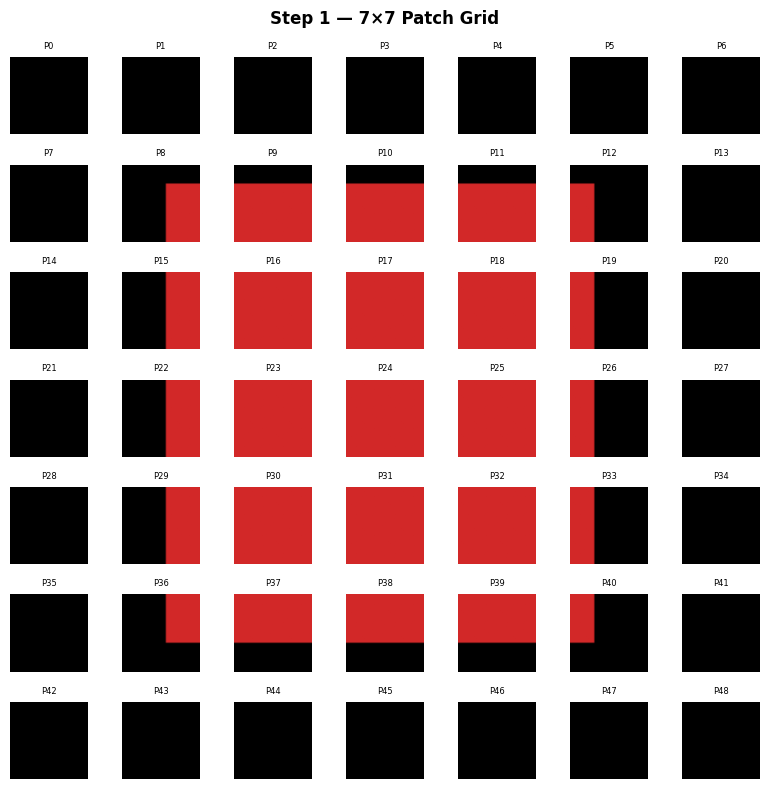


Step 2 — Patch Embedding (Linear Projection)
  ✓  Input  : [1, 3, 224, 224]
  ✓  Output : [1, 49, 768]  — 49 patches, each 768-dim
  →  Tiny numerical example (d=4):
    P0 flat → Linear(3072,4) = [0.0, 0.0, 0.0, 0.0]
  →  L2 norm of each patch embedding (7×7 heatmap):
                       
     ▒▒ ██ ██ ██ ▒▒    
     ▓▓ ██ ██ ██ ▒▒    
     ▓▓ ██ ██ ██ ▒▒    
     ▓▓ ██ ██ ██ ▒▒    
     ▒▒ ▓▓ ▓▓ ▓▓ ▒▒    
                       


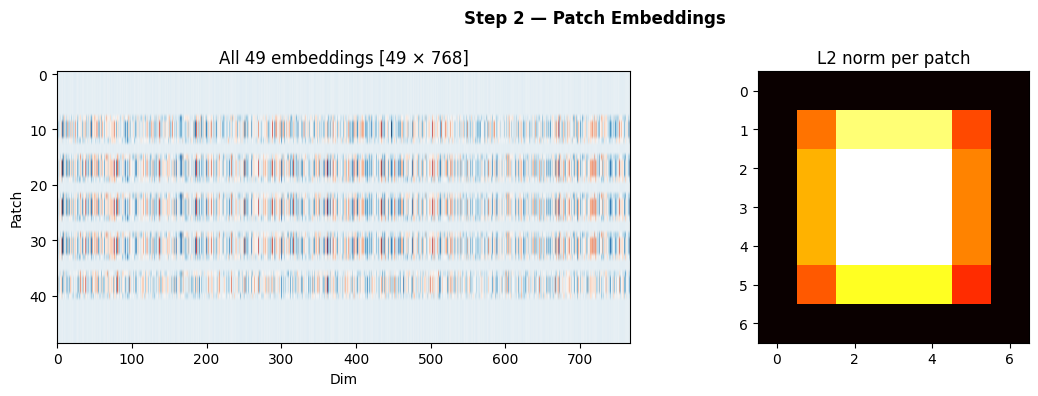


Step 3 — Prepend [CLS] Token
  ✓  Before : [1, 49, 768]  (49 patch tokens)
  ✓  After  : [1, 50, 768]  (CLS + 49 patches)
  →  [CLS] first 6 dims (random init): [-1.089, -0.9528, 0.1688, 0.0146, 0.9175, 1.2884]
  →  [CLS] will learn to aggregate all patch information through attention

Step 4 — Positional Encoding
  ✓  50 position embeddings × 768 dims each
  ✓  Output : [1, 50, 768]  (unchanged shape)
  →  Numerical example — position 25 (centre patch):
    patch_embedding[24] (4 dims): [-0.4343, -0.0682, 0.2281, -0.1821]
    position_embed[24]  (4 dims): [0.0205, -0.0032, -0.0105, -0.0019]
    sum (final_input)   (4 dims): [-0.4138, -0.0714, 0.2176, -0.1839]
  →  Each patch now 'knows' where it came from in the image

Step 5 — Transformer Encoder (12 Blocks)
  ✓  Architecture: 12 blocks × (MHSA + FFN)
  ✓  MHSA: 12 heads × 64 dims each
  ✓  FFN:  768 → 3072 → 768  (mlp_ratio=4)
  ✓  Total encoder parameters: 85,054,464  (~85.1M)
  →  Running forward pass …
  ✓  Done in 0.41s  |  out

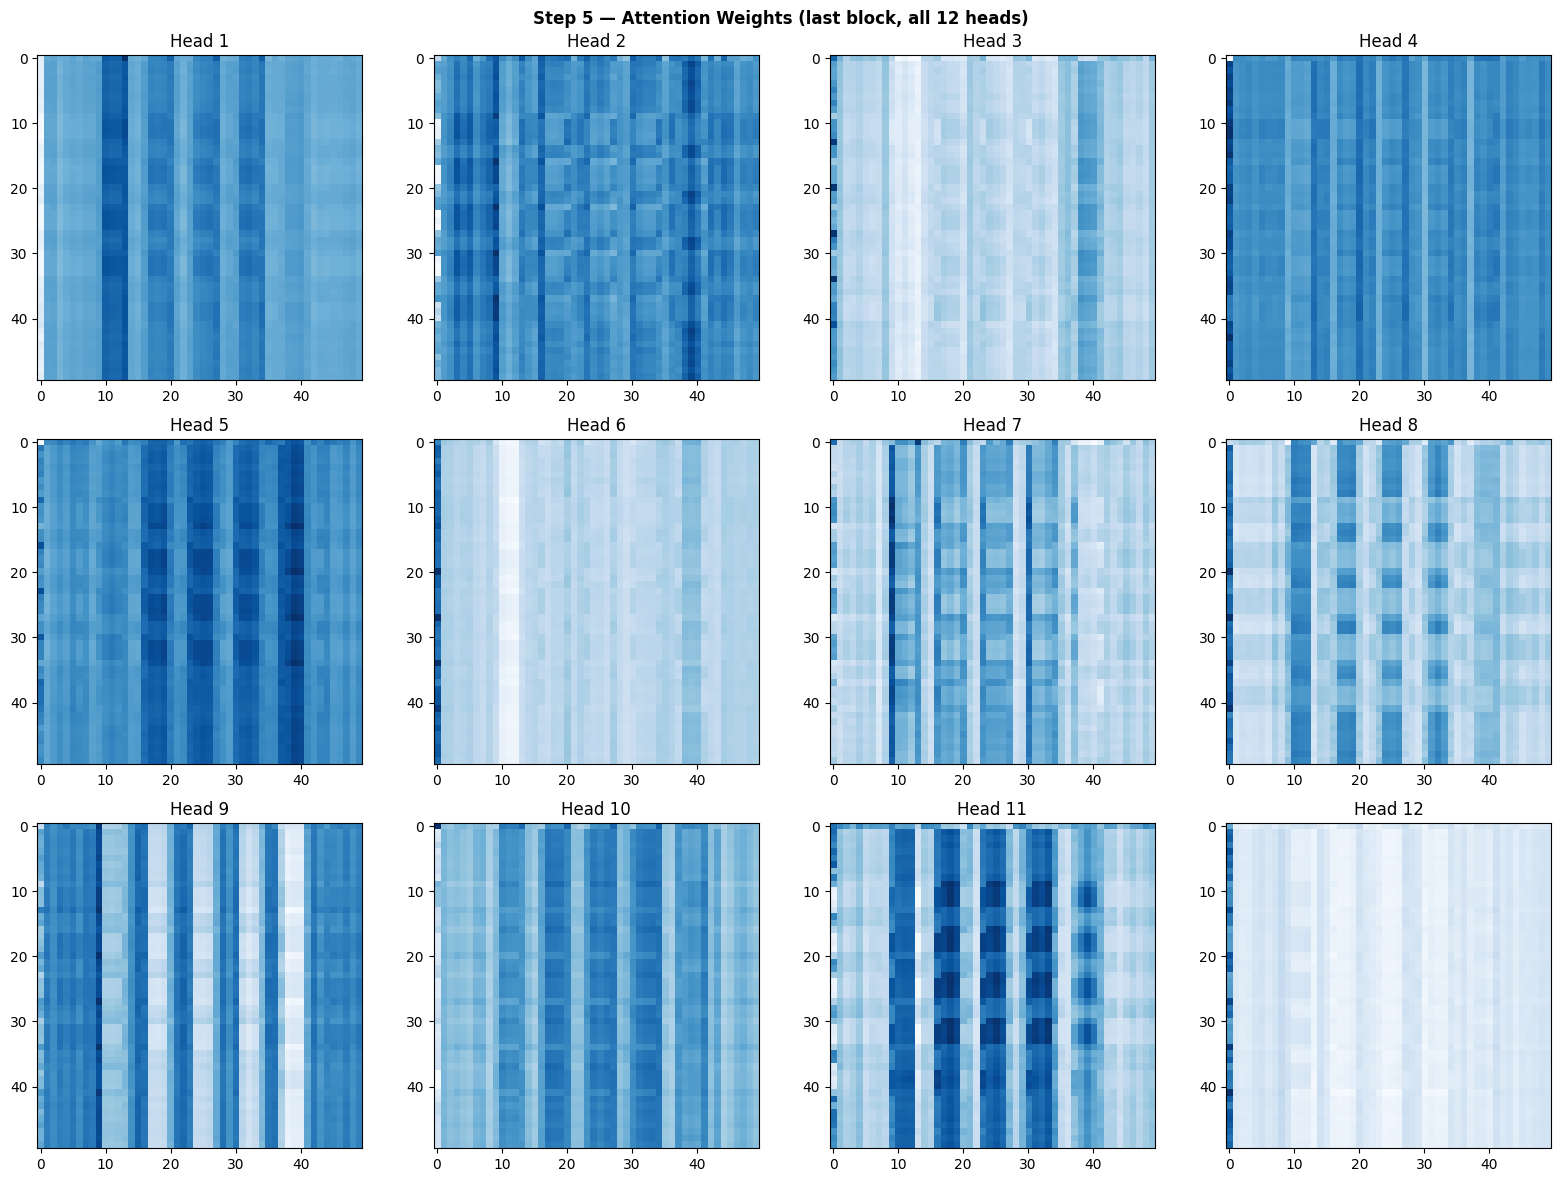


Step 6 — Extract [CLS] Token
  ✓  Encoder output : [1, 50, 768]  (50 tokens)
  ✓  [CLS] extracted: [768]   ← global image representation
  →  [CLS] statistics:
    min  = -2.9842
    max  = +3.0194
    mean = +0.0000
    std  = 1.0006
    L2   = 27.7128
  →  First 8 dims: [-1.1121, -1.1744, -0.2031, -0.0816, 1.3473, 0.87, 1.2293, -0.9844]

Step 7 — Projection Head
  ✓  Classification head: [768] → Linear(768,1000) → softmax → [1000]
  →  Top-5 class indices & probabilities (random weights, untrained):
    class  724  ██  0.0059
    class  300  ██  0.0045
    class  235  █  0.0039
    class  684  █  0.0036
    class  536  █  0.0036
  ✓  CLIP head: [768] → Linear(768,512) → L2-norm → [512]
  →  CLIP embedding L2 norm : 1.000000  (should be 1.0)
  →  First 8 dims           : [-0.033, -0.024, 0.0343, -0.0251, 0.0283, 0.0124, 0.0413, 0.0083]

Step 1-7 — Full ViT-B/32 forward pass — shape trace
  ✓  Total parameters: 87,848,448  (~88M)
  →  Shape trace:
  Input image               → [1, 3, 

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# Entry point
# ══════════════════════════════════════════════════════════════════════════════

def main():
    parser = argparse.ArgumentParser(
        description="ViT-B/32 from scratch — all 7 steps",
        formatter_class=argparse.RawDescriptionHelpFormatter,
        epilog=textwrap.dedent("""
            Examples:
              python vit_runner.py
              python vit_runner.py --step 2
              python vit_runner.py --clip
              python vit_runner.py --image apple.jpg --clip --no-plots
        """)
    )
    parser.add_argument("--image",    type=str, default=None,
                        help="path to an image file (default: download apple)")
    parser.add_argument("--step",     type=int, default=0, choices=range(0, 8),
                        help="run only this step 1-7, or 0 for all (default: 0)")
    parser.add_argument("--clip",     action="store_true",
                        help="run CLIP zero-shot demo after the ViT steps")
    parser.add_argument("--no-plots", action="store_true",
                        help="skip matplotlib visualisations")
    args = parser.parse_args([]) # Modified this line to pass an empty list

    show_plots = not args.no_plots

    # ── banner ─────────────────────────────────────────────────────────────
    print(f"\n{BOLD}{CYAN}{'═'*60}{RESET}")
    print(f"{BOLD}{CYAN}  Vision Transformer (ViT-B/32) — from scratch{RESET}")
    print(f"{BOLD}{CYAN}  7 steps · PyTorch · optional CLIP comparison{RESET}")
    print(f"{BOLD}{CYAN}{'═'*60}{RESET}")

    img, img_tensor = load_image(args.image)
    info(f"Image tensor: {shape_str(img_tensor)}")

    step = args.step

    if step == 0 or step == 1:
        patches  = run_step1(img_tensor, show_plots)

    if step == 0 or step == 2:
        embedded = run_step2(img_tensor, show_plots)

    if step == 0 or step == 3:
        if step == 3:
            embedded = PatchEmbedding(32, 768)(img_tensor)
        with_cls = run_step3(embedded, show_plots)

    if step == 0 or step == 4:
        if step == 4:
            embedded = PatchEmbedding(32, 768)(img_tensor)
            cls      = nn.Parameter(torch.randn(1,1,768))
            with_cls = torch.cat([cls.expand(1,-1,-1), embedded], dim=1)
        final_input = run_step4(with_cls, show_plots)

    if step == 0 or step == 5:
        if step == 5:
            embedded    = PatchEmbedding(32, 768)(img_tensor)
            cls         = nn.Parameter(torch.randn(1,1,768))
            with_cls    = torch.cat([cls.expand(1,-1,-1), embedded], dim=1)
            pos         = nn.Parameter(torch.randn(1,50,768)*0.02)
            final_input = with_cls + pos
        enc_out = run_step5(final_input, show_plots)

    if step == 0 or step == 6:
        if step == 6:
            model = ViTB32()
            with torch.no_grad():
                _, cls_out = model(img_tensor)
            enc_out = cls_out.unsqueeze(0).unsqueeze(0)   # fake [1,50,768]
            # just show CLS
            enc_out = torch.cat([cls_out.unsqueeze(0).unsqueeze(0),
                                 torch.zeros(1,49,768)], dim=1)
        cls_vec = run_step6(enc_out, show_plots)

    if step == 0 or step == 7:
        if step == 7:
            model = ViTB32()
            with torch.no_grad():
                _, cls_vec = model(img_tensor)
        run_step7(cls_vec, show_plots)

    if step == 0:
        run_full_pipeline(img_tensor, show_plots)

    if args.clip:
        run_clip_demo(img, show_plots)

    print(f"\n{BOLD}{CYAN}{'═'*60}{RESET}")
    print(f"{BOLD}{CYAN}  Done.{RESET}")
    print(f"{BOLD}{CYAN}{'═'*60}{RESET}\n")


if __name__ == "__main__":
    main()
